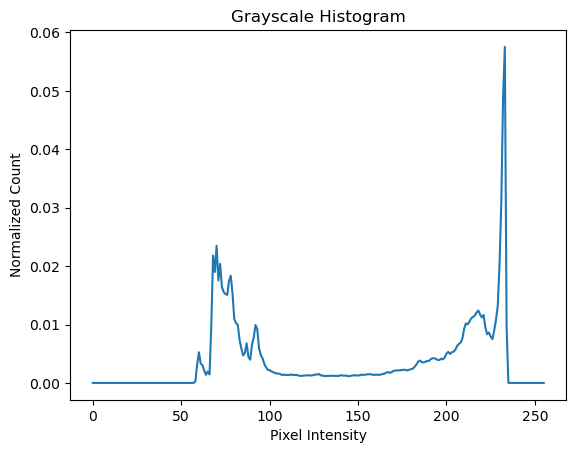

In [2]:
from skimage import io, measure, img_as_ubyte, img_as_float
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = io.imread("../data/vertebra.png", as_gray=True)

# Flatten image to 1D array
pixels = img.ravel()

# Compute histogram
hist, bins = np.histogram(pixels, bins=256, range=(0, 256))

# Normalize histogram if needed (common for ML features)
hist = hist / hist.sum()

# Plot
plt.plot(hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Normalized Count")
plt.show()



235 57 156.17451903807614 66.89854589155094


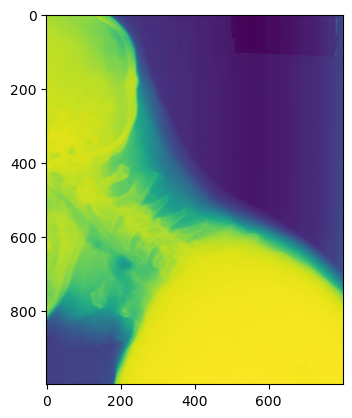

In [3]:
print(img.max(), img.min(), img.mean(), img.std())
plt.imshow(img)

In [4]:
def histogram_stretch(img_in):
    """
    Stretches the histogram of an image 
    :param img_in: Input image
    :return: Image, where the histogram is stretched so the min values is 0 and the maximum value 255
    """
    # img_as_float will divide all pixel values with 255.0
    img_float = img_as_float(img_in)
    min_val = img_float.min()
    max_val = img_float.max()
    min_desired = 0.0
    max_desired = 1.0
	
    # Do something here
    img_out = (max_desired-min_desired)/(max_val-min_val)*(img_float - min_val) + min_desired

    # img_as_ubyte will multiply all pixel values with 255.0 before converting to unsigned byte
    return img_as_ubyte(img_out)

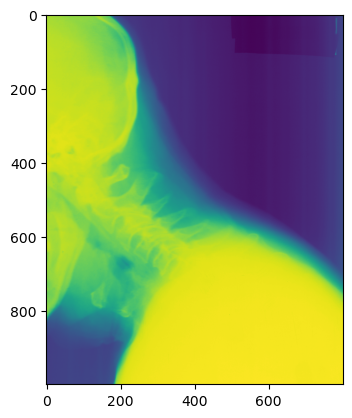

In [5]:
img_stretched = histogram_stretch(img)
plt.imshow(img_stretched)

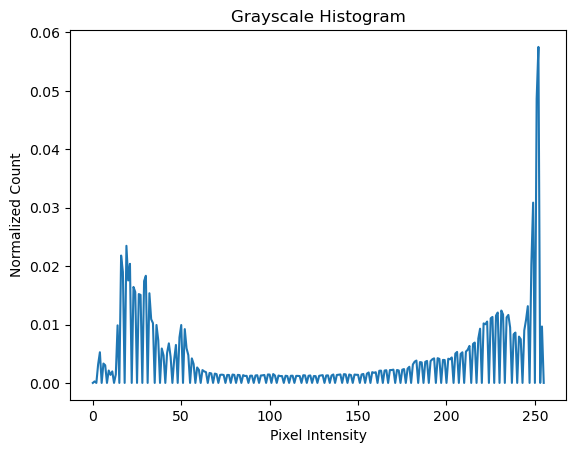

In [6]:
# Flatten image to 1D array
pixels = img_stretched.ravel()

# Compute histogram
hist, bins = np.histogram(pixels, bins=256, range=(0, 256))

# Normalize histogram if needed (common for ML features)
hist = hist / hist.sum()

# Plot
plt.plot(hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Normalized Count")
plt.show()

In [7]:
def gamma_map(img, gamma):
    # img_as_float will divide all pixel values with 255.0
    img_float = img_as_float(img)
    
    return img_as_ubyte(pow(img_float, gamma))

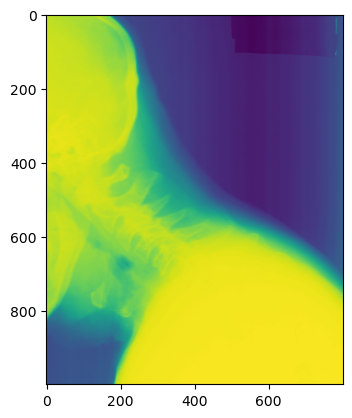

In [8]:
img_gamma = gamma_map(img, 0.5)
plt.imshow(img_gamma)

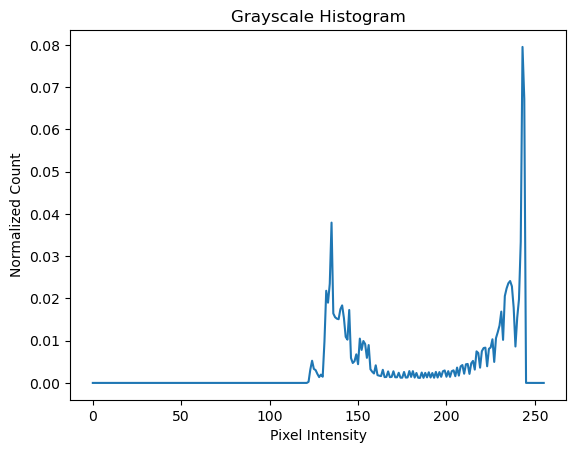

In [9]:
# Flatten image to 1D array
pixels = img_gamma.ravel()

# Compute histogram
hist, bins = np.histogram(pixels, bins=256, range=(0, 256))

# Normalize histogram if needed (common for ML features)
hist = hist / hist.sum()

# Plot
plt.plot(hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Normalized Count")
plt.show()

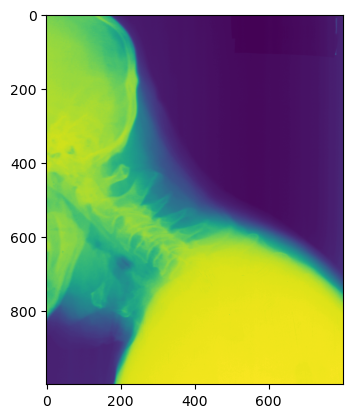

In [10]:
img_gamma = gamma_map(img, 2)
plt.imshow(img_gamma)

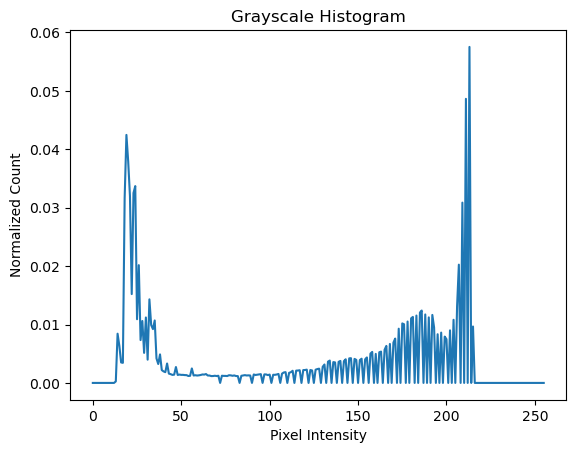

In [11]:
# Flatten image to 1D array
pixels = img_gamma.ravel()

# Compute histogram
hist, bins = np.histogram(pixels, bins=256, range=(0, 256))

# Normalize histogram if needed (common for ML features)
hist = hist / hist.sum()

# Plot
plt.plot(hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Normalized Count")
plt.show()

In [12]:
def threshold_image(img_in, thres):
    """
    Apply a threshold in an image and return the resulting image
    :param img_in: Input image
    :param thres: The treshold value in the range [0, 255]
    :return: Resulting image (unsigned byte) where background is 0 and foreground is 255
    """
    mask = img_in > thres
    return img_as_ubyte(mask)

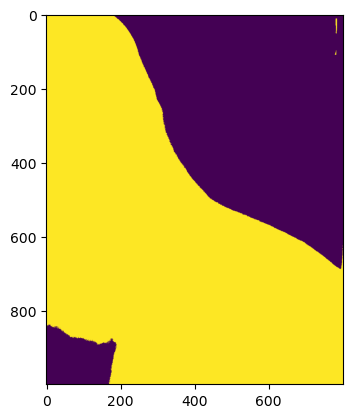

In [13]:
thresholded_img = threshold_image(img, 100)
plt.imshow(thresholded_img)

In [14]:
print(img.shape)
print(img[0][0])        

(998, 800)
210


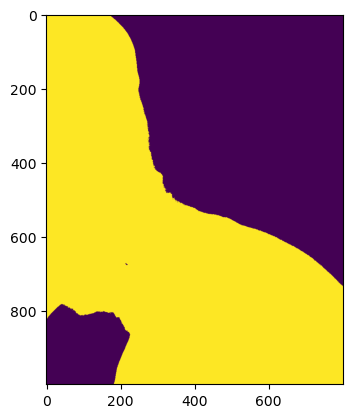

In [16]:
from skimage.filters import threshold_otsu
otsu_T = threshold_otsu(img)
otsu_img = img > otsu_T
plt.imshow(otsu_img)

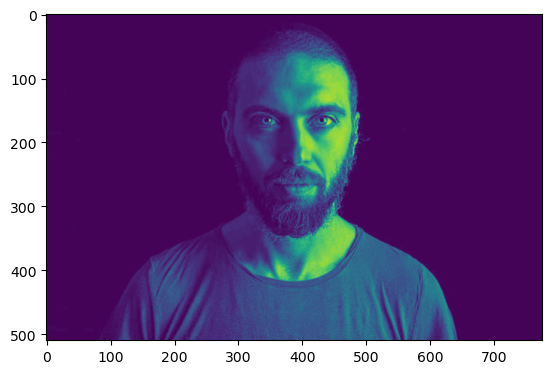

In [17]:
img_dark = io.imread("../data/dark_background.png", as_gray=True)
plt.imshow(img_dark)

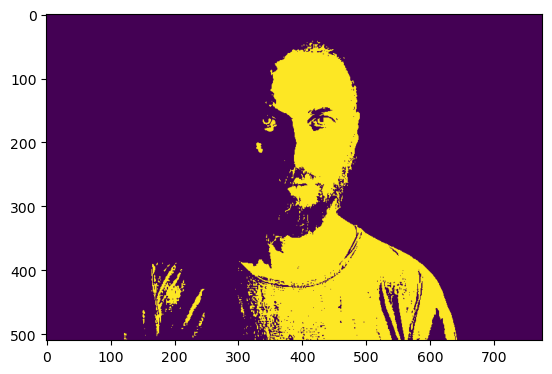

In [19]:
dark_otsu_T = threshold_otsu(img_dark)
otsu_dark_img = img_dark > dark_otsu_T
plt.imshow(otsu_dark_img)